In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision.datasets as datasets
import os
%matplotlib inline

/home/ddsukhoverkhova/.conda/envs/mc_lib_env/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_data(Jd, l, num_conf, T, num_temps, batch_size, shuffle_opt, opt='train'):
    datasets = []
    for j in range(num_temps):

        with open(f'data_spins/{Jd}_{opt}/spins_{l}_{T[j]}.npy', 'rb') as f:
            x = np.load(f)    
        with open(f'data_spins/{Jd}_{opt}/answ_{l}_{T[j]}.npy', 'rb') as f:
            y = np.load(f)

        tensor_x = torch.Tensor(x).unsqueeze(1)
        tensor_y = torch.from_numpy(y).type(torch.float32)

        datasets.append(TensorDataset(tensor_x, tensor_y))


    dataset = torch.utils.data.ConcatDataset(datasets)

    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle_opt)

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 2)
        self.pool = nn.MaxPool2d(2, 2)
        self.act_hid = nn.ReLU()
        self.fc1 = nn.Linear(64*int(l/2-1)*int(l/2-1), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = self.act_hid(x)
        x = x.view(-1, 64*int(l/2-1)*int(l/2-1))
        x = self.fc1(x)
        x = self.act_hid(x)
        x = self.fc2(x)
        return x

In [4]:
def train(train_dataloader, num_epoch, criterion, batch_size):
    model = Net()
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-4)
    act = nn.Sigmoid()

    for epoch in range(num_epoch):  
        running_loss = 0.0
        accuracy = 0.0
        pbar = tqdm(enumerate(train_dataloader), total=len(train_dataloader))
        for i, data in pbar:
            inputs, labels = data

            optimizer.zero_grad()
            outputs = model(inputs)
            #outputs = act(outputs)

            outputs = outputs.squeeze(1) # к одной размерности с labels

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            accuracy += (batch_size - sum(abs(labels - act(outputs)))).float().mean()

            pbar.set_description(
                    f"Loss: {running_loss/((i+1)*batch_size)} "
                    f"Accuracy: {accuracy * 100  / ((i+1)*batch_size)}"
            )

    print('Training completed')
    return model

In [5]:
def testing(model, test_dataloader, criterion, batch_size):
    outp = []
    errors = []
    accuracy = 0.0
    act = nn.Sigmoid()
    with torch.no_grad():
        for i, data in enumerate(test_dataloader):
            inputs, labels = data
            outputs = model(inputs)
            #outputs = act(outputs)
            outputs = outputs.squeeze(1)
            outp.append(act(outputs).item())
            loss = criterion(outputs, labels)
            errors.append(loss.item())

            accuracy += (1 - sum(abs(labels - act(outputs)))).float().mean()

    print("Accuracy = {}".format(accuracy / len(test_dataloader)))
    return outp, errors

In [8]:
'''model = Net()
model.load_state_dict(torch.load(PATH))
model.eval()'''

'model = Net()\nmodel.load_state_dict(torch.load(PATH))\nmodel.eval()'

In [7]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

num_temps = 20
Jd = 0.0
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 1.0, T_c + 1.0, num_temps)

L = [10, 20, 30, 40]
num_conf_tr = 2048
num_conf_ts = 512
num_epoch = 1
outputs = []
errors = []

models = []

criterion = nn.BCEWithLogitsLoss()     
    
for i in range(len(L)):
    l = L[i]
    train_dataloader = load_data(Jd, l, num_conf_tr, T, num_temps, batch_size=4, shuffle_opt=True, opt='train')
    print(f'Start training for L = {l}')
    model = train(train_dataloader, num_epoch, criterion, batch_size=4)
    
    PATH = f'models/{L[i]}_{Jd}_{T[0]}_{T[-1]}_{num_temps}.pt'
    torch.save(model.state_dict(), PATH)

Start training for L = 10


Loss: 0.05492106273548245 Accuracy: 86.68704986572266: 100%|██████████| 10240/10240 [00:44<00:00, 230.19it/s] 


Training completed
Start training for L = 20


Loss: 0.02517123023902741 Accuracy: 94.44417572021484: 100%|██████████| 10240/10240 [01:05<00:00, 157.32it/s] 


Training completed
Start training for L = 30


Loss: 0.015927118383063953 Accuracy: 96.6202163696289: 100%|██████████| 10240/10240 [03:16<00:00, 52.12it/s] 


Training completed
Start training for L = 40


Loss: 0.011192595918841806 Accuracy: 97.61003112792969: 100%|██████████| 10240/10240 [05:19<00:00, 32.04it/s]


Training completed


In [6]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

num_temps = 20
Jd = 0.0
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 1.0, T_c + 1.0, num_temps)

L = [10, 20, 30, 40]

num_conf_tr = 2048
num_conf_ts = 512
outputs = []
errors = []

criterion = nn.BCEWithLogitsLoss()     

for i in range(len(L)):
    l = L[i]
    model = Net()
    PATH = f'models/{L[i]}_{Jd}_{T[0]}_{T[-1]}_{num_temps}.pt'
    model.load_state_dict(torch.load(PATH))
    model.eval()
    test_dataloader = load_data(Jd, l, num_conf_ts, T, num_temps, batch_size=1, shuffle_opt=False, opt='test')
    outp_i, errors_i = testing(model, test_dataloader, criterion, batch_size=1)
    outputs.append(outp_i)
    errors.append(errors_i)
    

Accuracy = 0.8809627294540405
Accuracy = 0.9515858888626099
Accuracy = 0.969970703125
Accuracy = 0.9773181080818176


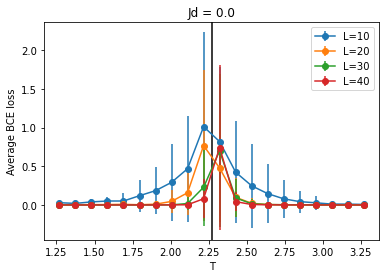

In [13]:
def errs(l_ind):
    return [sum(errors[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_err(l_ind):
    return [np.std(errors[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, errs(0), yerr=stds_err(0), marker='o', label='L=10')
plt.errorbar(T, errs(1), yerr=stds_err(1), marker='o', label='L=20')
plt.errorbar(T, errs(2), yerr=stds_err(2), marker='o', label='L=30')
plt.errorbar(T, errs(3), yerr=stds_err(3), marker='o', label='L=40')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()

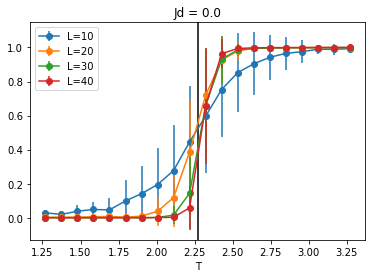

In [12]:
def outs(l_ind):
    return [sum(outputs[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_out(l_ind):
    return [np.std(outputs[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, outs(0), yerr=stds_out(0), marker='o', label='L=10')
plt.errorbar(T, outs(1), yerr=stds_out(1), marker='o', label='L=20')
plt.errorbar(T, outs(2), yerr=stds_out(2), marker='o', label='L=30')
plt.errorbar(T, outs(3), yerr=stds_out(3), marker='o', label='L=40')


plt.title('Jd = 0.0')
plt.xlabel('T')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()

In [14]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

num_temps = 20
Jd = -0.3
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 1.0, T_c + 1.0, num_temps)

L = [10, 20, 30, 40]

num_conf_tr = 2048
num_conf_ts = 512
outputs = []
errors = []

criterion = nn.BCEWithLogitsLoss()     

for i in range(len(L)):
    l = L[i]
    model = Net()
    T_c_ = get_crit_T[0.0]
    T_ = np.linspace(T_c_ - 1.0, T_c_ + 1.0, num_temps)
    PATH = f'models/{L[i]}_0.0_{T_[0]}_{T_[-1]}_{num_temps}.pt'
    model.load_state_dict(torch.load(PATH))
    model.eval()
    test_dataloader = load_data(Jd, l, num_conf_ts, T, num_temps, batch_size=1, shuffle_opt=False, opt='test')
    outp_i, errors_i = testing(model, test_dataloader, criterion, batch_size=1)
    outputs.append(outp_i)
    errors.append(errors_i)
    

Accuracy = 0.9051381349563599
Accuracy = 0.9607275128364563
Accuracy = 0.9737210273742676
Accuracy = 0.9784903526306152


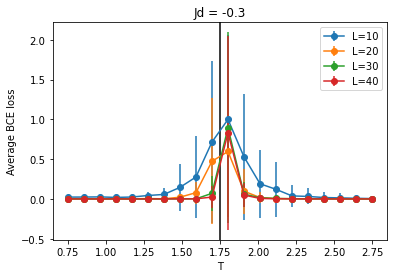

In [16]:
def errs(l_ind):
    return [sum(errors[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_err(l_ind):
    return [np.std(errors[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, errs(0), yerr=stds_err(0), marker='o', label='L=10')
plt.errorbar(T, errs(1), yerr=stds_err(1), marker='o', label='L=20')
plt.errorbar(T, errs(2), yerr=stds_err(2), marker='o', label='L=30')
plt.errorbar(T, errs(3), yerr=stds_err(3), marker='o', label='L=40')

plt.title('Jd = -0.3')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()

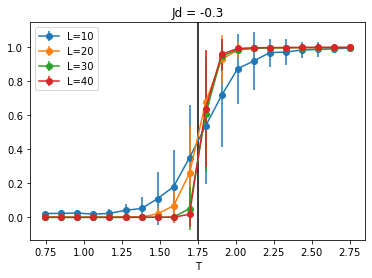

In [15]:
def outs(l_ind):
    return [sum(outputs[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_out(l_ind):
    return [np.std(outputs[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, outs(0), yerr=stds_out(0), marker='o', label='L=10')
plt.errorbar(T, outs(1), yerr=stds_out(1), marker='o', label='L=20')
plt.errorbar(T, outs(2), yerr=stds_out(2), marker='o', label='L=30')
plt.errorbar(T, outs(3), yerr=stds_out(3), marker='o', label='L=40')


plt.title('Jd = -0.3')
plt.xlabel('T')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()

In [17]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

num_temps = 20
Jd = -0.5
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 1.0, T_c + 1.0, num_temps)

L = [10, 20, 30, 40]

num_conf_tr = 2048
num_conf_ts = 512
outputs = []
errors = []

criterion = nn.BCEWithLogitsLoss()     

for i in range(len(L)):
    l = L[i]
    model = Net()
    T_c_ = get_crit_T[0.0]
    T_ = np.linspace(T_c_ - 1.0, T_c_ + 1.0, num_temps)
    PATH = f'models/{L[i]}_0.0_{T_[0]}_{T_[-1]}_{num_temps}.pt'
    model.load_state_dict(torch.load(PATH))
    model.eval()
    test_dataloader = load_data(Jd, l, num_conf_ts, T, num_temps, batch_size=1, shuffle_opt=False, opt='test')
    outp_i, errors_i = testing(model, test_dataloader, criterion, batch_size=1)
    outputs.append(outp_i)
    errors.append(errors_i)
    

Accuracy = 0.9011332392692566
Accuracy = 0.9681298136711121
Accuracy = 0.9723821878433228
Accuracy = 0.9755880236625671


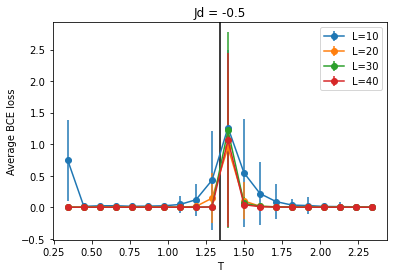

In [18]:
def errs(l_ind):
    return [sum(errors[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_err(l_ind):
    return [np.std(errors[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, errs(0), yerr=stds_err(0), marker='o', label='L=10')
plt.errorbar(T, errs(1), yerr=stds_err(1), marker='o', label='L=20')
plt.errorbar(T, errs(2), yerr=stds_err(2), marker='o', label='L=30')
plt.errorbar(T, errs(3), yerr=stds_err(3), marker='o', label='L=40')

plt.title('Jd = -0.5')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()

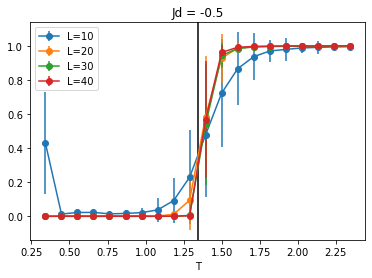

In [19]:
def outs(l_ind):
    return [sum(outputs[l_ind][i*512:(i+1)*512])/512 for i in range(num_temps)]

def stds_out(l_ind):
    return [np.std(outputs[l_ind][i*512:(i+1)*512]) for i in range(num_temps)]

plt.errorbar(T, outs(0), yerr=stds_out(0), marker='o', label='L=10')
plt.errorbar(T, outs(1), yerr=stds_out(1), marker='o', label='L=20')
plt.errorbar(T, outs(2), yerr=stds_out(2), marker='o', label='L=30')
plt.errorbar(T, outs(3), yerr=stds_out(3), marker='o', label='L=40')


plt.title('Jd = -0.5')
plt.xlabel('T')
plt.axvline(x=T_c, color='black')
plt.legend()
plt.show()